# Aufgabe 3

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color
from skimage.io import imread

In [47]:
imgs = [imread(f"slicing/bild{i}.jpg") for i in range(1,4)]

## 3.1

Ziel: Blüten, Knospen und Zweige isolieren, Rest auf Grau (128) setzen.

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

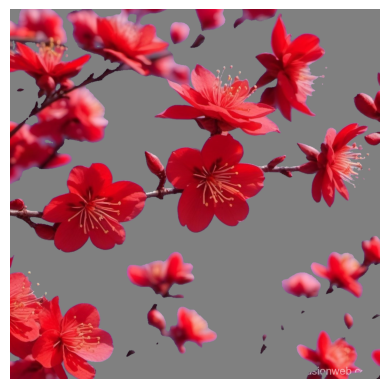

In [48]:
img_1 = imgs[0]

R = img_1[:,:,0].astype(float)
G = img_1[:,:,1].astype(float)
B = img_1[:,:,2].astype(float)

mask = (B > R) & (B > G)

img_1[mask] = 128

plt.imshow(img_1)
plt.axis("off")

## 3.2

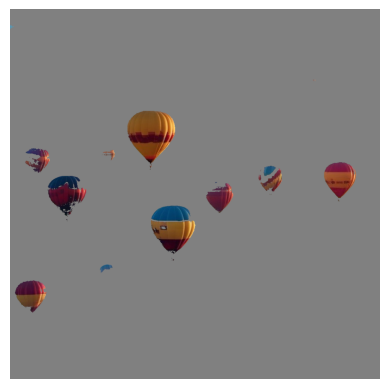

In [63]:
img_2 = imgs[1].copy()

img_2_hsv = color.rgb2hsv(img_2)

S = img_2_hsv[:, :, 1] # extract saturation

mask_2 = (S < 0.47)

img_2[mask_2] = 128

plt.imshow(img_2)
plt.axis("off")
plt.show()

### Begründung: HSV-Farbenraum

- **Ballons:** Haben stark saturierte Farben
- **Hintergrund:** Ist schwach saturiert
Daher kann rein auf Basis der Saturierung das Slicing durchgeführt werden.

## 3.3

Text(0.5, 1.0, 'Rote Äpfel isoliert (HSV Hue-Kanal)')

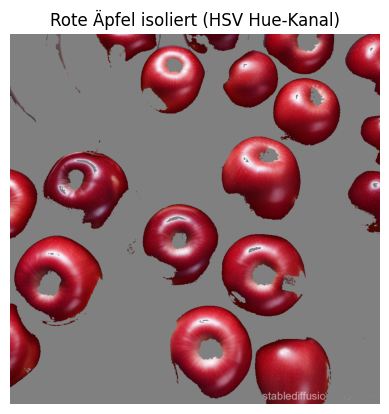

In [65]:
img_3 = imgs[2].copy()

# HSV-basiertes Color Slicing
# Konvertiere RGB zu HSV für bessere Farbtrennung
img_3_hsv = color.rgb2hsv(img_3)
H = img_3_hsv[:,:,0]  # Hue-Kanal
V = img_3_hsv[:,:,2]  # Value-Kanal

H_grad = H * 360

lower_bound = 5     # untere Grenze Grad-Bereich für Rot
upper_bound = 290.  # obere Grenze Grad-Bereich für Rot

R = img_3[:, :, 0]
G = img_3[:, :, 1]
B = img_3[:, :, 2]

# Rote Äpfel haben Hue um 0 (0° - 30° bzw. 330° - 360°)
# In HSV normalisiert: Hue ∈ [0, 1]
# Rot: [0, 0.03]  [0.97, 1]
red_apples = ((H_grad < lower_bound) | (H_grad > upper_bound)) & (V > 0.25)

# Ergebnisbild: Original wo Maske wahr, sonst Grau (128)
result_hsv = np.ones_like(img_3) * 128
result_hsv[red_apples] = img_3[red_apples]

plt.imshow(result_hsv.astype(np.uint8))
plt.axis("off")
plt.title("Rote Äpfel isoliert (HSV Hue-Kanal)")

### Begründung: HSV-Farbraum mit Hue-Kanal

- **Rote Äpfel:** Haben Hue-Werte um 0° (rot), Bananen um 45-60° (gelb) → saubere Trennung in einem Kanal
- **Hue-Kanal:** Ist farbtintensitätsunabhängig und trennt Rot von Gelb optimal
- **Saturation:** Filtert unsättigte Farben (Grau, dunkler Hintergrund) aus und isoliert nur intensive Farben
- **Vorteil:** Einfacher, direkter und effizienter als RGB (dort wären mehrere korrelierte Bedingungen nötig)